In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve,auc

In [48]:
state=0

In [49]:
X, y=make_classification(n_samples=13,n_features=3,n_informative=3,n_repeated=0,n_redundant=0,n_classes=2,random_state=state)

In [50]:
print(X)
print(y)

[[-0.68884242  1.91020474 -1.37674977]
 [-1.67104293 -0.69847945  1.62955952]
 [ 0.95044215 -1.08457183  0.20047613]
 [-2.39072447  2.41649117 -1.69842329]
 [-0.69314746 -0.03844523 -0.75974403]
 [-1.22558726  0.55610367  0.8846891 ]
 [ 1.07688381  0.36991644 -0.09509276]
 [-0.79599022 -2.92879538 -1.46902731]
 [-2.14446266  0.17598194 -0.37773326]
 [ 0.8992065   1.79011796  0.70762906]
 [ 1.87617375 -0.15781813 -0.14501964]
 [-1.54850774 -0.34489055  1.6267815 ]
 [ 0.50556125  1.46891511  0.58250878]]
[1 0 0 1 1 0 1 0 0 0 0 0 1]


In [51]:
X_new=[]
for row in X:
  new_row=[]
  for element in row:
    if(element<0):
      new_row.append(0)
    elif(element>0):
      new_row.append(1)
  X_new.append(new_row)

In [52]:
X_new,y

([[0, 1, 0],
  [0, 0, 1],
  [1, 0, 1],
  [0, 1, 0],
  [0, 0, 0],
  [0, 1, 1],
  [1, 1, 0],
  [0, 0, 0],
  [0, 1, 0],
  [1, 1, 1],
  [1, 0, 0],
  [0, 0, 1],
  [1, 1, 1]],
 array([1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1]))

In [53]:
X_train,X_test,y_train,y_test=train_test_split(X_new,y,test_size=0.2,random_state=state)
data=[]
for x,y in zip(X_train,y_train):
  x.append(int(y))
  data.append(x)
data_df=pd.DataFrame(data=data,columns=['f1','f2','f3','y'])
data_df

,f1,f2,f3,y
0,1,0,0,0
1,1,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0
5,1,1,1,0
6,0,1,0,1
7,0,1,0,1
8,0,1,1,0
9,1,1,1,1


In [54]:
tree=DecisionTreeClassifier(random_state=state)
tree.fit(data_df.loc[:,['f1','f2','f3']],data_df.loc[:,'y'])

DecisionTreeClassifier(random_state=0)

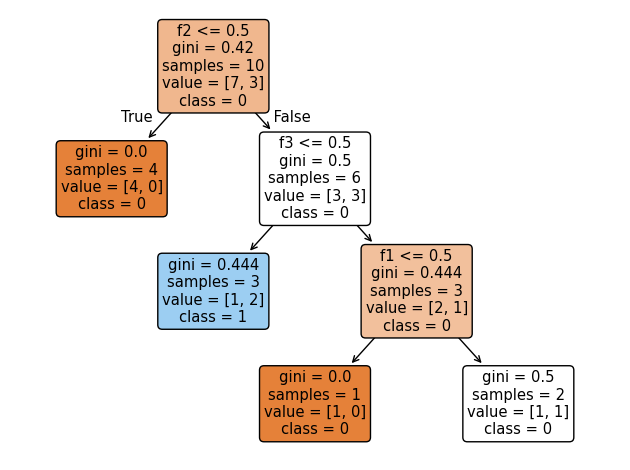

In [55]:
sklearn.tree.plot_tree(tree,feature_names=['f1','f2','f3'],class_names=['0','1'],filled=True,rounded=True)
plt.tight_layout()

In [56]:
print(X_test)
print(y_test)

[[1, 1, 0], [0, 0, 1], [0, 0, 0]]
[1 0 1]


In [57]:
preds=tree.predict(X_test)
print(preds)
print(y_test)

[1 0 0]
[1 0 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
